# Introduction to Neural Networks and Deep Learning

## Neural Networks

A neural network is a system of interconnected neurons (nodes) that work together to process complex data. These networks can learn and make intelligent decisions on their own. The basic idea behind neural networks is inspired by the workings of the human brain, though the analogy is not precise.

Neural networks consist of layers of nodes: an input layer, one or more hidden layers, and an output layer. Each node in a hidden layer transforms the values from the previous layer with a weighted linear summation followed by a non-linear activation function.

The 1980s saw a resurgence in neural network research, with the introduction of the backpropagation algorithm, which efficiently computes gradients for the network's weights. This allowed neural networks to learn from data and adjust their weights to improve predictions, making them useful for a wide range of tasks.

## Deep Learning

Deep learning is a subset of machine learning where neural networks—particularly those with many hidden layers—are used to model complex patterns in data. The "deep" in deep learning refers to the number of layers through which the data is transformed. More layers allow for more levels of abstraction and complexity in modeling the data.

The concept of deep learning has been around for decades, but it wasn't until the mid-2000s that it gained significant traction. This was due to the availability of large amounts of data (big data) and substantial increases in computing power, particularly through the use of GPUs.

Deep learning has led to significant advances in many areas, including computer vision, natural language processing, and reinforcement learning.

Deep learning architectures include:

- Deep neural networks (DNNs)
- Convolutional neural networks (CNNs)
- Recurrent neural networks (RNNs)
- Long short-term memory networks (LSTMs)
- Generative adversarial networks (GANs)

## Historical Overview

- **1950s-1960s**: Early research in neural networks, including the development of the perceptron.
- **1970s**: The AI winter began, partly due to the limitations of neural networks at the time, such as the inability to solve non-linearly separable problems like the XOR problem.
- **1980s**: The resurgence of neural networks with the introduction of backpropagation.
- **1990s**: Support Vector Machines and other algorithms gained popularity over neural networks.
- **Mid-2000s**: Deep learning started to become prominent due to advances in computing power and data availability.
- **2010s-Present**: Deep learning has become a dominant approach in AI, achieving state-of-the-art results in various fields.

The breakthrough came in the late 2000s and early 2010s when researchers started to train deep neural networks with much success, thanks to:

- The availability of large datasets
- Advances in computing power, particularly GPUs
- Improvements in training algorithms and network architectures

Since then, deep learning has been at the forefront of many AI breakthroughs and continues to push the boundaries of what machines can learn and accomplish.

## Applications of Deep Learning

Deep learning has a broad range of applications, many of which are revolutionizing industries and scientific research:

- **Computer Vision**: Image and video recognition, object detection, image generation, and facial recognition
- **Natural Language Processing (NLP)**: Language translation, sentiment analysis, and chatbots (including LLMs and ChatGPT)
- **Speech Recognition**: Voice control systems, transcription, and real-time translation
- **Healthcare**: Disease detection, drug discovery, and personalized medicine
- **Autonomous Vehicles**: Self-driving cars and drones
- **Gaming**: Non-player character (NPC) behavior, procedural content generation, and game testing
- **Finance**: Fraud detection, algorithmic trading, and credit scoring
- **Robotics**: Humanoid robots, industrial automation, and service robots

# Perceptron

The perceptron is one of the earliest and simplest models of a neural network. Developed in 1957 by Frank Rosenblatt, the perceptron was designed to mimic the way a single neuron in the brain processes information. It takes a set of inputs, applies a linear combination with weights and a bias, and outputs a binary result through an activation function.

![neuron](../assets/neuron.png)

It is a binary classifier that maps its input $ \mathbf{x} $ (a real-valued vector) to an output value $ f(\mathbf{x}) $ (a single binary value).

The perceptron can only solve linearly separable problems, which is a significant limitation. However, its development laid the groundwork for more complex neural networks.

### Mathematical Formulation

![perceptron](../assets/perceptron.png)

Given an input vector $ \mathbf{x} $ and weight vector $ \mathbf{w} $, the perceptron's output $ f(\mathbf{x}) $ is defined as:

$$ f(\mathbf{x}) = \begin{cases} 
1 & \text{if } \mathbf{w} \cdot \mathbf{x} + b > 0 \\
0 & \text{otherwise}
\end{cases} $$

where $ \mathbf{w} \cdot \mathbf{x} $ is the dot product of the weights and input vector, and $ b $ is the bias term.

### Learning Algorithm

The perceptron learns by updating the weights and bias based on the errors made in predictions. The update rule is:

$$ \mathbf{w}_{(t+1)} = \mathbf{w}_{(t)} + \eta (y - \hat{y}) \mathbf{x} $$
$$ b_{(t+1)} = b_{(t)} + \eta (y - \hat{y}) $$

where $ \eta $ is the learning rate, $ y $ is the true label, and $ \hat{y} $ is the predicted label.

In [3]:
import numpy as np

In [4]:
# define the Perceptron class, which is a simple linear binary classifier
class Perceptron(object):
    # set the number of epochs and learning rate as parameters for training
    def __init__(self, no_of_inputs, epochs=100, learning_rate=0.01):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.weights = np.zeros(no_of_inputs + 1)
    
    # define the predict method, which takes inputs and returns the predicted output (0 or 1)
    def predict(self, inputs):
        summation = np.dot(inputs, self.weights[1:]) + self.weights[0]
        return 1 if summation > 0 else 0

    # define the train method, which takes training inputs and labels and updates the weights
    def train(self, training_inputs, labels):
        for _ in range(self.epochs):
            for inputs, label in zip(training_inputs, labels):
                prediction = self.predict(inputs)
                self.weights[1:] += self.learning_rate * (label - prediction) * inputs
                self.weights[0] += self.learning_rate * (label - prediction)

In [11]:
# array of training inputs for the AND logic gate, where each input is a pair of binary values (0 or 1)
training_inputs = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
# array of labels for the AND logic gate, where the output is 1 only when both inputs are 1
labels = np.array([1, 0, 0, 0])

In [12]:
# create an instance of the Perceptron class with 2 inputs, and train it using the training inputs and labels
perceptron = Perceptron(no_of_inputs=2)
perceptron.train(training_inputs, labels)

In [13]:
print(perceptron.predict(np.array([1, 1])))
print(perceptron.predict(np.array([1, 0])))
print(perceptron.predict(np.array([0, 1])))
print(perceptron.predict(np.array([0, 0])))

1
0
0
0


A single perceptron can learn AND because it's linearly separable — one straight line cleanly separates the (1,1) point from the other three. The training converges, so the weights settle into a correct boundary instead of oscillating. The next section on MLPs is what you'd use for XOR.

## Multi-Layer Perceptron (MLP)

A Multi-Layer Perceptron (MLP) is a class of feedforward artificial neural network that consists of at least three layers of nodes: an input layer, one or more hidden layers, and an output layer. Unlike the Perceptron, which can only separate linearly separable classes, MLPs can classify non-linearly separable classes.

A Multi-Layer Perceptron (MLP) is a specific type of neural network and can be considered as one of the foundational architectures from which more complex neural network models have evolved.

![mlp](../assets/multi_layer_perceptron.png)

### Mathematical Formulation

Each neuron in the MLP applies an activation function $ \phi $ to the weighted sum of its inputs. The output of the $ j $-th neuron in the $ l $-th layer is:

$$ o_j^l = \phi \left( \sum_{i} w_{ij}^l o_i^{l-1} + b_j^l \right) $$

where 
- $ w_{ij}^l $ is the weight connecting the $ i $-th neuron in the $ (l-1) $-th layer to the $ j $-th neuron in the $ l $-th layer
- $ b_j^l $ is the bias term for the $ j $-th neuron in the $ l $-th layer
- $ o_i^{l-1} $ is the output of the $ i $-th neuron in the $ (l-1) $-th layer

An MLP with at least one hidden layer and a sufficient number of neurons is a universal function approximator, as proven by the universal approximation theorem. This means that it can, in theory, learn any continuous function to an arbitrary level of accuracy, given enough neurons and data.

### Non-linear Activation Functions

Non-linear activation functions are crucial in MLPs (and neural networks), as they allow the network to capture complex patterns and interactions in the data. Without non-linearity, a neural network, regardless of how many layers it had, would still behave like a single-layer perceptron, only capable of modeling linear separations.

A few common non-linear activation functions include:

![sigmoid_tanh](../assets/sigmoid_tanh.jpeg)

1. **Sigmoid Function**:
   $$ \sigma(x) = \frac{1}{1 + e^{-x}} $$
   The sigmoid function squashes the input values to be between 0 and 1, which can be interpreted as probabilities. It is often used for the output layer in binary classification problems.

2. **Hyperbolic Tangent Function (tanh)**:
   $$ \tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} $$
   The tanh function outputs values between -1 and 1. It is zero-centered, which generally helps with the convergence during training.

3. **Rectified Linear Unit (ReLU)**:
   $$ \text{ReLU}(x) = \max(0, x) $$
   The ReLU function outputs the input directly if it is positive, otherwise, it outputs zero. It has become the default activation function for many types of neural networks because it helps with faster training and reduces the likelihood of vanishing gradients.

![relu](../assets/relu.png)

### Backpropagation Training

Backpropagation is the algorithm used for training neural networks, including MLPs. It consists of two main phases: the forward pass and the backward pass.

1. **Forward Pass (Feed-Forward)**:
   During the forward pass, the input data is passed through the network layer by layer until the output layer is reached. The output is then used to compute the loss function, which measures the difference between the network's prediction and the actual target values. A common choice for the loss function in classification tasks is the cross-entropy loss.

![ff](../assets/feedforward.png)

<br>

2. **Backward Pass (Backpropagation)**:

![bp](../assets/backprop.png)

   In the backward pass, gradients of the loss function with respect to the network's weights are computed using the chain rule of calculus, in a process known as *gradient descent*.

Backpropagation allows neural networks to learn from their mistakes, adjusting the weights to improve performance on the training data. With the right adjustments over many iterations, the network can converge to a state where it makes accurate predictions on unseen data.

### Gradient Descent

Gradient descent is an optimization algorithm used to minimize a function by iteratively moving in the direction of steepest descent, as defined by the negative of the gradient. In the context of neural networks, gradient descent is used during backpropagation to update the weights and biases in order to minimize the loss function.

![loss_functions](../assets/loss_functions.png)

Let's consider a neural network with a loss function $ \mathcal{L} $. The goal of training is to find the set of weights $ \mathbf{W} $ and biases $ \mathbf{b} $ that minimize $ \mathcal{L} $. The gradient descent update rule for each weight $ W_{ij}^{(l)} $ in layer $ l $ is given by:

$$ W_{ij}^{(l)} := W_{ij}^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial W_{ij}^{(l)}} $$

Similarly, the update rule for each bias $ b_i^{(l)} $ is:

$$ b_i^{(l)} := b_i^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial b_i^{(l)}} $$

![learning_rate](../assets/learning_rate.png)

In these equations, $ \eta $ is the learning rate, a hyperparameter that controls the size of the steps taken towards the minimum of $ \mathcal{L} $. The partial derivatives $ \frac{\partial \mathcal{L}}{\partial W_{ij}^{(l)}} $ and $ \frac{\partial \mathcal{L}}{\partial b_i^{(l)}} $ represent the gradients of the loss function with respect to the weights and biases, respectively.

During backpropagation, these gradients are computed using the **chain rule**. For a given layer $ l $, the gradient of the loss with respect to the activation $ o_i^{(l)} $ is calculated based on the gradients from the subsequent layer $ l+1 $:

$$ \frac{\partial \mathcal{L}}{\partial o_i^{(l)}} = \sum_{k} \frac{\partial \mathcal{L}}{\partial z_k^{(l+1)}} \frac{\partial z_k^{(l+1)}}{\partial o_i^{(l)}} $$

where $ z_k^{(l+1)} $ is the weighted input to the activation function in the next layer, and the sum is over all neurons $ k $ in layer $ l+1 $ that receive inputs from neuron $ i $ in layer $ l $.

The gradient of the loss with respect to the weighted input $ z_k^{(l+1)} $ is then calculated by applying the derivative of the activation function $ \phi $ used in layer $ l+1 $:

$$ \frac{\partial \mathcal{L}}{\partial z_k^{(l+1)}} = \frac{\partial \mathcal{L}}{\partial o_k^{(l+1)}} \phi'(z_k^{(l+1)}) $$

Finally, the gradients with respect to the weights and biases are computed as:

$$ \frac{\partial \mathcal{L}}{\partial W_{ij}^{(l)}} = \frac{\partial \mathcal{L}}{\partial z_i^{(l)}} o_j^{(l-1)} $$
$$ \frac{\partial \mathcal{L}}{\partial b_i^{(l)}} = \frac{\partial \mathcal{L}}{\partial z_i^{(l)}} $$

These gradients are used to update the weights and biases in the opposite direction of the gradient, hence the term "gradient descent."

![gradient_descent](../assets/gradient_descent.png)

Adjusting the weights consists of multiple iterations. A new step is taken for each iteration and calculate a new weight. Using the initial weight and the gradient and learning rate, the subsequent weights can be determined.

There are several variants of gradient descent, including:

- **Batch Gradient Descent**: Computes the gradient of the loss function with respect to the parameters for the entire training dataset.
- **Stochastic Gradient Descent (SGD)**: Computes the gradient for each training example and updates the parameters accordingly.
- **Mini-batch Gradient Descent**: A compromise between batch and stochastic versions, which computes the gradient against a subset of the training data at each step.

Choosing the right variant and learning rate requires careful tuning and is critical for the successful training of neural networks. Tinker with visualizing Neural Network variants -> https://playground.tensorflow.org

### Tutorial

Let's implement a simple neural network that utilizes feedforward and backpropagation algorithms.

In [36]:
np.random.seed(42)  # for reproducibility

# Define network architecture
input_size = 2  # Number of features
hidden_size = 2  # Number of neurons in the hidden layer
output_size = 1  # Number of neurons in the output layer

# Initialize weights and biases, for a simple feedforward neural network with one hidden layer
W1 = np.random.rand(input_size, hidden_size)
b1 = np.random.rand(hidden_size)
W2 = np.random.rand(hidden_size, output_size)
b2 = np.random.rand(output_size)

display(W1, b1, W2, b2)  # Display the initialized weights and biases

array([[0.37454012, 0.95071431],
       [0.73199394, 0.59865848]])

array([0.15601864, 0.15599452])

array([[0.05808361],
       [0.86617615]])

array([0.60111501])

![Screenshot 2026-07-13 211622.png](<attachment:Screenshot 2026-07-13 211622.png>)
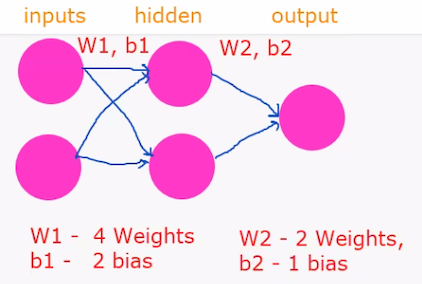

In [ ]:
# define using the sigmoid function as our activation function.

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

In [38]:
def feedforward(X, W1, b1, W2, b2):
    # from Input to hidden layer
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)  # Activation in hidden layer
    
    # from Hidden layer to output
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)  # Activation in output layer
    
    return A1, A2, Z1, Z2

In [ ]:
# define using the mean squared error (MSE) loss function to measure the difference between the predicted output and the true labels.

def mse_loss(y_true, y_pred):
    return ((y_true - y_pred) ** 2).mean()

In [40]:
# define the Backpropagation function to update weights and biases based on the loss gradient, to minimize the loss function, to improve the model's predictions.
def backprop(X, y_true, A1, A2, Z1, Z2, W1, b1, W2, b2, learning_rate=0.1):
    m = y_true.shape[0]  # Number of examples
    
    # Calculate derivatives
    dZ2 = A2 - y_true  # Derivative of loss with respect to Z2
    dW2 = (1 / m) * np.dot(A1.T, dZ2)  # Derivative of loss with respect to W2
    db2 = (1 / m) * np.sum(dZ2, axis=0)  # Derivative of loss with respect to b2
    
    dA1 = np.dot(dZ2, W2.T)  # Derivative of loss with respect to A1
    dZ1 = dA1 * sigmoid_derivative(Z1)  # Derivative of loss with respect to Z1 (sigmoid prime)
    dW1 = (1 / m) * np.dot(X.T, dZ1)  # Derivative of loss with respect to W1
    db1 = (1 / m) * np.sum(dZ1, axis=0)  # Derivative of loss with respect to b1
    
    # Update weights and biases
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    return W1, b1, W2, b2

In [41]:
# use some dummy data to train the network.

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_true = np.array([[0], [1], [1], [0]])

In [42]:
# initialize the hyperparameter: number of epochs to train the model
epochs = 10000
for epoch in range(epochs):
    # execute Feedforward function to get activations and pre-activations
    A1, A2, Z1, Z2 = feedforward(X, W1, b1, W2, b2)
    
    # call the Backpropagation function to update weights and biases
    W1, b1, W2, b2 = backprop(X, y_true, A1, A2, Z1, Z2, W1, b1, W2, b2)
    
    # Calculate loss (mean squared error)
    loss = np.mean((y_true - A2) ** 2)
    
    # Print loss every 1000 epochs to monitor training progress
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}: Loss = {loss:.4f}')

Epoch 0: Loss = 0.3247
Epoch 1000: Loss = 0.2406
Epoch 2000: Loss = 0.1940
Epoch 3000: Loss = 0.1169
Epoch 4000: Loss = 0.0180
Epoch 5000: Loss = 0.0041
Epoch 6000: Loss = 0.0016
Epoch 7000: Loss = 0.0009
Epoch 8000: Loss = 0.0005
Epoch 9000: Loss = 0.0003


In [50]:
# After training, we can use the trained model to make predictions on the input data.
A1, A2, Z1, Z2 = feedforward(X, W1, b1, W2, b2)

# Print the final predicted output after training A2, which is the output of the network after training on the dummy data.
print('Predicted output: A2')
print(A2)
print()
print('Final Weights and Biases:')
print('W1:', W1)
print('b1:', b1)
print('W2:', W2)
print('b2:', b2)
print()
print('Final pre-activation values:')
print('Z1:', Z1)
print('Z2:', Z2)

Predicted output: A2
[[0.01838   ]
 [0.98577795]
 [0.98574084]
 [0.01564593]]

Final Weights and Biases:
W1: [[4.61354626 6.57635076]
 [4.61807878 6.60246843]]
b1: [-7.06639055 -2.90927199]
W2: [[-10.54143724]
 [  9.79019631]]
b2: [-4.47507855]

Final pre-activation values:
Z1: [[-7.06639055 -2.90927199]
 [-2.44831176  3.69319644]
 [-2.45284429  3.66707877]
 [ 2.16523449 10.2695472 ]]
Z2: [[-3.97794107]
 [ 4.23863729]
 [ 4.23599426]
 [-4.14177453]]


*Gotcha: Z2 is not the final prediction—it is the raw score before the sigmoid squashes it. Only after applying sigmoid(Z2) do you get A2, the interpretable output that matches the shape and scale of your labels.*

# Introduction to PyTorch

PyTorch is an open-source machine learning library developed by Facebook's AI Research lab (FAIR). It is one of the most popular deep learning frameworks. It is widely used for applications such as computer vision and natural language processing and is known for its flexibility, ease of use, and dynamic computational graph. PyTorch is particularly popular in the research community due to its flexibility and ease of experimentation, but it is also gaining traction in the industry for development and deployment of machine learning models.

## Key Features of PyTorch:

- **Dynamic Computation Graph**: Also known as define-by-run paradigm, where the graph is built on the fly as operations are created. This feature makes it easy to change the network architecture during runtime and is beneficial for working with variable-length inputs and outputs.

- **Pythonic Nature**: PyTorch is deeply integrated with Python, making it intuitive to learn and use. It leverages the power of Python's libraries and allows for easy debugging using standard Python debugging tools.

- **GPU Acceleration**: PyTorch supports CUDA, which allows it to efficiently compute forward and backward passes on GPUs for faster training of models.

- **TorchScript**: A way to create serializable and optimizable models from PyTorch code. This allows for models to be run independently from Python, which is useful for deploying models in production environments.

- **Extensive Library**: PyTorch includes a wide range of tools and libraries for various tasks in machine learning, like torchvision for computer vision, torchaudio for audio processing, and torchtext for natural language processing.

- **Community and Ecosystem**: PyTorch has a large and active community that contributes to a growing ecosystem of tools, libraries, and extensions.

- **Autograd Module**: Provides automatic differentiation for all operations on Tensors. It is a define-by-run framework, which means that the backpropagation is defined by how your code is run, and every single iteration can be different.

- **Distributed Training**: PyTorch supports native distributed training, making it easy to scale computation across multiple GPUs and machines.

- **Pretrained Models**: PyTorch provides a number of pre-trained models which can be used for transfer learning, fine-tuning, or as a starting point for custom solutions.

## Loss Functions

### Negative Log Likelihood (NLL) Loss

Negative Log Likelihood Loss is a loss function commonly used in classification tasks, particularly when the output of the neural network represents the log probabilities of the classes. It is often used in conjunction with the softmax layer that normalizes the network's raw output scores into probabilities.

The NLL loss is defined as:

$$ L(y, \hat{y}) = -\sum_{i=1}^{N} \log(\hat{y}_i[y_i]) $$

where:
- $N$ is the number of samples,
- $y$ is the true label (index of the correct class),
- $\hat{y}_i$ is the predicted probability of the $i$-th sample for its true class $y_i$.

In PyTorch, the NLL loss is implemented as `torch.nn.NLLLoss`. It expects the inputs to be log probabilities, which can be obtained by applying the `torch.log` function to the output of a softmax layer or, more commonly, by using the `torch.nn.LogSoftmax` layer.

### Cross-Entropy Loss

Cross-Entropy Loss combines LogSoftmax and NLL Loss in one single class. It is useful when training a classification problem with C classes. It is defined as:

$$ L(y, \hat{y}) = -\sum_{i=1}^{N} \sum_{j=1}^{C} y_{i,j} \log(\hat{y}_{i,j}) $$

where $y_{i,j}$ is a binary indicator of whether class label $j$ is the correct classification for observation $i$, and $\hat{y}_{i,j}$ is the predicted probability of observation $i$ being of class $j$.

In PyTorch, it is implemented as `torch.nn.CrossEntropyLoss`.

### Mean Squared Error Loss

Mean Squared Error (MSE) Loss is used for regression tasks and measures the squared difference between the target and the output:

$$ L(y, \hat{y}) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$

In PyTorch, it is implemented as `torch.nn.MSELoss`.

### Binary Cross-Entropy Loss

Binary Cross-Entropy Loss is used for binary classification tasks:

$$ L(y, \hat{y}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right] $$

In PyTorch, it is implemented as `torch.nn.BCELoss`. For outputs that are probabilities, you would use `torch.nn.BCEWithLogitsLoss`, which combines a sigmoid layer and the BCELoss in one single class.

## Optimizers

Optimizers are algorithms or methods used to change the attributes of a neural network, such as weights and learning rate, to reduce the losses. Optimizers help to minimize the loss function. Optimizers guide the training process by telling the network how to update its weights via backpropagation. Gradient Descent that we learnt above is one of the optimizers. The goal of optimization is to find the best parameters for the model to perform the task at hand.

### Stochastic Gradient Descent (SGD)

SGD is the most classical approach to fitting linear classifiers and convex functions. It's defined by the update rule:

$$ \theta = \theta - \eta \cdot \nabla_{\theta}J(\theta; x^{(i)}; y^{(i)}) $$

where $\theta$ is the parameter, $\eta$ is the learning rate, and $\nabla_{\theta}J$ is the gradient of the loss function $J$ with respect to the parameter $\theta$.

In PyTorch, SGD is implemented as `torch.optim.SGD`.

### RMSprop

RMSprop is an adaptive learning rate method. It divides the learning rate for a weight by a running average of the magnitudes of recent gradients for that weight.

In PyTorch, RMSprop is implemented as `torch.optim.RMSprop`.

### Adagrad

Adagrad adapts the learning rate to the parameters, performing larger updates for infrequent and smaller updates for frequent parameters. It's well-suited for dealing with sparse data.

In PyTorch, Adagrad is implemented as `torch.optim.Adagrad`.

### Adam Optimizer

Adam (Adaptive Moment Estimation) is an optimizer that can be used instead of the classical stochastic gradient descent (SGD) to update network weights iteratively based on training data. Adam combines the best properties of the AdaGrad and RMSProp algorithms to provide an optimization algorithm that can handle sparse gradients on noisy problems.

Key Features of Adam:

- Adaptive Learning Rate: Maintains a learning rate for each network weight (parameter) and separately adapts them as learning unfolds.
- Computationally Efficient: Requires little memory and is invariant to diagonal rescale of the gradients.
- Well Suited for Problems: That are large in terms of data and/or parameters.
- Appropriate for Non-Stationary Objectives: And problems with very noisy and/or sparse gradients.

In PyTorch, the Adam optimizer is implemented as `torch.optim.Adam`.

### Adadelta

Adadelta is an extension of Adagrad that seeks to reduce its aggressive, monotonically decreasing learning rate. It does this by restricting the window of accumulated past gradients to some fixed size.

In PyTorch, Adadelta is implemented as `torch.optim.Adadelta`.

### Adamax

Adamax is a variant of Adam based on the infinity norm. It can be seen as a generalization of Adam that is more stable in cases where the gradients' infinity norm is very large or very small.

In PyTorch, Adamax is implemented as `torch.optim.Adamax`.

## Building a MLP (Fully Connected Neural Network) with PyTorch

We will learn how to build, train, and evaluate a MLP (also known as fully connected neural network) using PyTorch.

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

/opt/anaconda3/envs/dl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's use the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database), which consists of 28x28 pixel grayscale images of handwritten digits (0-9).

In [17]:
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

# Download and load the training data
trainset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform)
# bring in the DataLoader to handle batching and shuffling of the training data
trainloader = DataLoader(trainset, batch_size=64, shuffle=True) # tune the hyperparameter: batch size of 64 and shuffle the training data for better generalization. depend on compute power and memory, adjust the batch size to a larger value for faster training, but it may require more memory.

# Download and load the test data
testset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=False, transform=transform)
# bring in the DataLoader to handle batching of the test data
testloader = DataLoader(testset, batch_size=64, shuffle=False) # tune the hyperparameter: batch size of 64 and do not shuffle the test data. depend on compute power and memory, adjust the batch size to a larger value for faster training, but it may require more memory.

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:08<00:00, 1178480.16it/s]


Extracting /Users/gel/.pytorch/MNIST_data/MNIST/raw/train-images-idx3-ubyte.gz to /Users/gel/.pytorch/MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 85680.20it/s]


Extracting /Users/gel/.pytorch/MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to /Users/gel/.pytorch/MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:03<00:00, 483362.18it/s] 


Extracting /Users/gel/.pytorch/MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz to /Users/gel/.pytorch/MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 2547202.67it/s]

Extracting /Users/gel/.pytorch/MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /Users/gel/.pytorch/MNIST_data/MNIST/raw



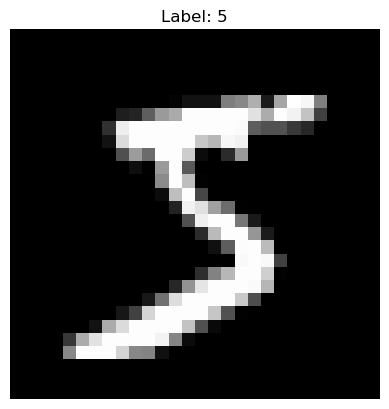

In [18]:
# Let's take a look at this dataset we loaded. It is a dataset of handwritten digits, 
# where each image is a 28x28 pixel grayscale image, and the label is the digit (0-9) that 
# the image represents. Feel free to explore the dataset further on your own!
import matplotlib.pyplot as plt

image, label = trainset[0]

# undo normalization: [-1,1] -> [0,1]
image = image * 0.5 + 0.5

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [19]:
# Let's check the shape of the image tensor. It should be (1, 28, 28) 
# since it's a grayscale image with one channel.
image,label = trainset[0]
print(image.shape)
print(label)

torch.Size([1, 28, 28])
5


In [20]:
# Let's create a simple neural network with two hidden layers

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)  # first layer: Flatten the image. 28 rows * 28 columns = 784 input features, 128 neurons in the first hidden layer
        self.fc2 = nn.Linear(128, 64)  # first hidden layer: 128 neurons in the first hidden layer, 64 neurons in the second hidden layer
        self.fc3 = nn.Linear(64, 10)  # second hidden layer: 64 neurons in the second hidden layer, 10 units in the output layer - one for each digit. number of output corresponds to the number of classes (10 for digits 0-9).

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # Flatten the input tensor
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

![Screenshot 2026-07-13 214031.png](<attachment:Screenshot 2026-07-13 214031.png>)
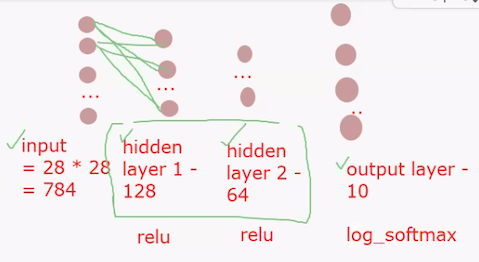

In [21]:
# Instantiate the network
model = Net()
print(model)

Net(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [22]:
# next, define the loss function and the optimizer. The loss function measures how well the model is performing, and the optimizer updates the model's weights based on the gradients computed during backpropagation.

# use Negative log-likelihood loss, which is a common loss function for multi-class classification problems. It measures the difference between the predicted probability distribution and the true distribution (one-hot encoded labels). The model outputs log probabilities, and NLLLoss expects log probabilities as input, making it suitable for this task.
criterion = nn.NLLLoss()

# use Adam optimizer, which is an adaptive learning rate optimization algorithm that has been designed specifically for training deep neural networks. It combines the advantages of two other popular optimization algorithms: AdaGrad and RMSProp. Adam computes individual adaptive learning rates for different parameters from estimates of first and second moments of the gradients. It is computationally efficient, has little memory requirements, and is well suited for problems that are large in terms of data and/or parameters.
optimizer = optim.Adam(model.parameters(), lr=0.003)

In [31]:
# Let's check the number of samples in the training and test datasets. This will give us an idea of how much data we have for training and evaluating our model.
print(f"Number of samples in training dataset: {len(trainloader.dataset)}")
print(f"Number of samples in test dataset: {len(testloader.dataset)}")

# Display the number of batches in the training loader
print(f"Number of batches in training loader: {len(trainloader)}")
num_batches = len(trainloader)/64 
print(f"Number of batches in training loader (calculated): {num_batches}")

Number of samples in training dataset: 60000
Number of samples in test dataset: 10000
Number of batches in training loader: 938
Number of batches in training loader (calculated): 14.65625


In [32]:
# Train the network for a few epochs.

epochs = 5

for epoch in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        # Zero the gradients
        optimizer.zero_grad()

        # call the feedForward pass
        output = model(images)
        
        # Compute the loss
        loss = criterion(output, labels)
        
        # apply the Backward pass
        loss.backward()
        
        # Update weights based on the gradients computed during backpropagation. The optimizer.step() function updates the model's weights using the gradients calculated in the loss.backward() step. This is where the learning happens, as the model adjusts its parameters to minimize the loss function.
        optimizer.step()
        
        running_loss += loss.item()
    else:
        print(f"Training loss: {running_loss / len(trainloader)}")

Training loss: 0.33492971356235335
Training loss: 0.16979287437764978
Training loss: 0.13695098149246657
Training loss: 0.12367104104102485
Training loss: 0.10900419245514749


In [ ]:
# Let's check the performance of our network on the test dataset.
correct = 0
total = 0

# Turn off gradients for validation to save memory and computations
with torch.no_grad():
    for images, labels in testloader:
        output = model(images)
        # print(output)
        _, predicted = torch.max(output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {correct / total * 100}%")

Accuracy: 96.07%


# Building a Fully Connected Neural Network on the Titanic Dataset

In this tutorial, we will build a fully connected neural network using PyTorch to predict the survival of passengers from the Titanic dataset.

In [21]:
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

In [ ]:
titanic = sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [24]:
columns = ['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']
data = titanic[columns].copy()

In [25]:
data.shape

(891, 6)

In [26]:
data.dropna(subset=['embarked'], inplace=True)
data.reset_index(drop=True, inplace=True)

In [27]:
# Separate features and target
X = data.drop('survived', axis=1)
y = data['survived'].values

In [28]:
# Define numerical and categorical features
num_features = ['age', 'fare']
cat_features = ['pclass', 'sex', 'embarked']

In [29]:
# Create the preprocessing pipelines for both numerical and categorical data
num_pipeline = SimpleImputer(strategy='mean')
cat_pipeline = OneHotEncoder()

# Combine pipelines into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ])

# Preprocess the data
X_processed = preprocessor.fit_transform(X)

In [30]:
# Standardize the features
scaler = StandardScaler(with_mean=False)  # We use with_mean=False to work with sparse matrix
X_scaled = scaler.fit_transform(X_processed)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)

In [ ]:
# Convert to PyTorch tensors format
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)  # Convert sparse matrix to dense
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [32]:
# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [33]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [ ]:
class TitanicNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TitanicNet, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid() # because we are doing binary classification, we use sigmoid activation function in the output layer to get a probability score between 0 and 1.
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

In [35]:
# Initialize the network
input_size = X_train.shape[1]
hidden_size = 30  # You can tune this parameter
output_size = 1

model = TitanicNet(input_size, hidden_size, output_size)

In [ ]:
# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [37]:
epochs = 1000

for epoch in range(epochs):
    for inputs, labels in train_loader:
        labels = labels.view(-1, 1)  # Reshape the labels to match the output
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [20/1000], Loss: 0.7403
Epoch [40/1000], Loss: 0.3821
Epoch [60/1000], Loss: 0.3464
Epoch [80/1000], Loss: 0.2176
Epoch [100/1000], Loss: 0.2343
Epoch [120/1000], Loss: 0.3855
Epoch [140/1000], Loss: 0.4713
Epoch [160/1000], Loss: 0.3392
Epoch [180/1000], Loss: 0.2449
Epoch [200/1000], Loss: 0.5701
Epoch [220/1000], Loss: 0.1254
Epoch [240/1000], Loss: 0.1177
Epoch [260/1000], Loss: 0.6251
Epoch [280/1000], Loss: 0.1220
Epoch [300/1000], Loss: 0.4075
Epoch [320/1000], Loss: 0.5286
Epoch [340/1000], Loss: 0.1295
Epoch [360/1000], Loss: 0.3444
Epoch [380/1000], Loss: 0.2511
Epoch [400/1000], Loss: 0.2188
Epoch [420/1000], Loss: 0.4840
Epoch [440/1000], Loss: 0.2172
Epoch [460/1000], Loss: 0.1776
Epoch [480/1000], Loss: 0.1955
Epoch [500/1000], Loss: 0.4657
Epoch [520/1000], Loss: 0.2830
Epoch [540/1000], Loss: 0.5474
Epoch [560/1000], Loss: 0.0738
Epoch [580/1000], Loss: 0.5590
Epoch [600/1000], Loss: 0.0560
Epoch [620/1000], Loss: 0.2488
Epoch [640/1000], Loss: 0.2128
Epoch [660/1

In [38]:
y_preds = []
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for inputs, _ in test_loader:
        outputs = model(inputs)
        label = (outputs.data >= 0.5).float()
        y_preds.extend(label.flatten().numpy().tolist())

y_preds = np.array(y_preds)

In [39]:
accuracy = accuracy_score(y_test, y_preds)
precision = precision_score(y_test, y_preds)
recall = recall_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)

In [40]:
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

Accuracy: 0.73
Precision: 0.74
Recall: 0.53
F1 Score: 0.62
